# 01 — E-Perf-2: Latency CDF Comparison (WAFER vs Native vs eKuiper)

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** Numbers below are from macOS
> Apple Silicon shakedown runs. They are NOT thesis-grade canonical results.

Pipeline A at 1000 msg/s. Overlays CDF curves per system.
Reports HDR percentiles (p50, p95, p99, p999).

Produces **Figure 1** (latency CDF comparison).

In [1]:
import json, sys, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wafer_analysis.paths import find_latest_shakedown

RESULT_DIR = find_latest_shakedown('e-perf-2')
print(f'Using: {RESULT_DIR}')

Using: <repo>/eval/results/e-perf-2/shakedown-macos-2026-08-01T19-50-15Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
def load_latency_percentiles(system):
    """Load per-run percentile data from subscriber-metadata.json."""
    runs = sorted(glob.glob(f'{RESULT_DIR}/{system}/run-*'))
    records = []
    for run_dir in runs:
        meta_path = os.path.join(run_dir, 'subscriber-metadata.json')
        if not os.path.exists(meta_path):
            continue
        with open(meta_path) as f:
            d = json.load(f)
        records.append({
            'system': system,
            'min_ns': d.get('latency_min_ns', 0),
            'p50_ns': d.get('latency_p50_ns', 0),
            'p95_ns': d.get('latency_p95_ns', 0),
            'p99_ns': d.get('latency_p99_ns', 0),
            'p999_ns': d.get('latency_p999_ns', 0),
            'mean_ns': d.get('latency_mean_ns', 0),
            'max_ns': d.get('latency_max_ns', 0),
        })
    return pd.DataFrame(records)

wafer_df = load_latency_percentiles('wafer')
native_df = load_latency_percentiles('native')
ekuiper_df = load_latency_percentiles('ekuiper')
print(f'Loaded: wafer={len(wafer_df)}, native={len(native_df)}, ekuiper={len(ekuiper_df)}')

Loaded: wafer=30, native=30, ekuiper=30


In [4]:
# Median percentiles across runs
percentiles = ['p50_ns', 'p95_ns', 'p99_ns', 'p999_ns']
labels = ['p50', 'p95', 'p99', 'p999']

print('=== Latency Percentiles (median across runs, microseconds) ===')
print(f"{'':12} {'p50':>8} {'p95':>8} {'p99':>8} {'p999':>8}")
for name, df in [('WAFER', wafer_df), ('Native', native_df), ('eKuiper', ekuiper_df)]:
    vals = [df[p].median() / 1000 for p in percentiles]
    print(f'{name:12} {vals[0]:8.1f} {vals[1]:8.1f} {vals[2]:8.1f} {vals[3]:8.1f}')

=== Latency Percentiles (median across runs, microseconds) ===
                  p50      p95      p99     p999
WAFER          1289.7   1790.0   2163.7   6991.9
Native         1272.8   1749.5   2052.1   7137.3
eKuiper        1074.2   1563.1   1982.5   3781.6


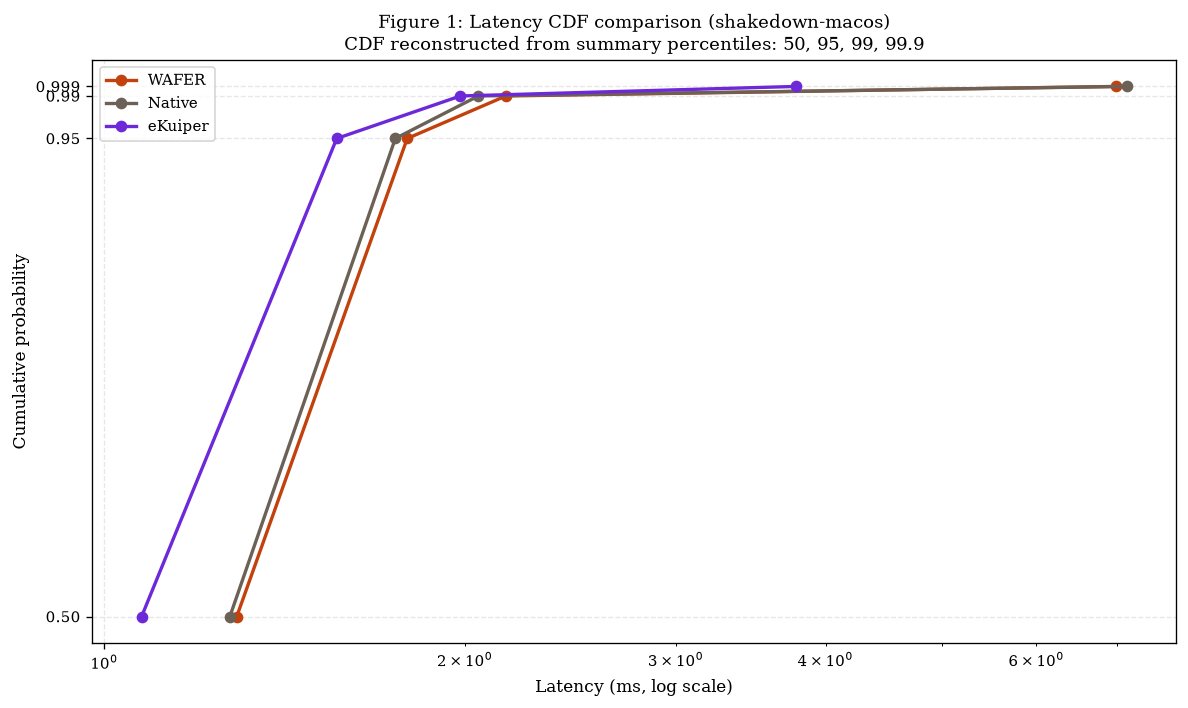

saved thesis figure to ../figures/e-perf-2/latency_cdf.pdf


In [5]:
# Simulated CDF from percentile data (approximate)
# Note: CDF is reconstructed from summary percentiles (50, 95, 99, 99.9);
# it is not derived from raw per-message latency samples.
from wafer_analysis.plots import SYSTEM_COLORS

fig, ax = plt.subplots(figsize=(10, 6))

systems_data = [
    ('WAFER',   wafer_df,   SYSTEM_COLORS['WAFER']),
    ('Native',  native_df,  SYSTEM_COLORS['Native']),
    ('eKuiper', ekuiper_df, SYSTEM_COLORS['eKuiper']),
]

cdf_points = [0.5, 0.95, 0.99, 0.999]

for name, df, color in systems_data:
    medians = [df[p].median() / 1e6 for p in percentiles]  # ns -> ms
    ax.plot(medians, cdf_points, 'o-', color=color, label=name, linewidth=2, markersize=6)

ax.set_xlabel('Latency (ms, log scale)')
ax.set_ylabel('Cumulative probability')
ax.set_title('Figure 1: Latency CDF comparison (shakedown-macos)\n'
             'CDF reconstructed from summary percentiles: 50, 95, 99, 99.9')
ax.legend()
ax.set_yticks(cdf_points)
ax.set_yticklabels(['0.50', '0.95', '0.99', '0.999'])
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('../../results/e-perf-2/latency-cdf-comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# T9: persist thesis figure to ../figures/e-perf-2/latency_cdf.{pdf,png}
_saved = save_figure(fig, 'e-perf-2/latency_cdf')
print(f'saved thesis figure to {_saved}')